# 📊 Análise de Dados — IEGM 2023 | Municípios do Estado do Ceará
---

## 🏛️ Contexto e Problemática

O **Índice de Efetividade da Gestão Municipal (IEGM)** é uma ferramenta de avaliação da qualidade da gestão pública idealizada pelo **Tribunal de Contas do Estado de São Paulo (TCESP)** em 2015, adotada posteriormente por outros Tribunais de Contas estaduais — incluindo o **Tribunal de Contas do Estado do Ceará (TCE-CE)**.

O IEGM avalia **sete dimensões** fundamentais da gestão municipal, cada uma representada por um índice específico:

| Índice | Área Avaliada |
|--------|---------------|
| **I-Amb** | Meio Ambiente |
| **I-Cidade** | Proteção das Cidades |
| **I-Educ** | Educação |
| **I-Fiscal** | Gestão Fiscal |
| **I-Gov TI** | Governança de Tecnologia da Informação |
| **I-Saúde** | Saúde |
| **I-Plan** | Planejamento |

A nota final de cada índice é classificada em **faixas de desempenho** que refletem o grau de efetividade das políticas públicas municipais:

| Faixa | Classificação |
|-------|---------------|
| **A** | Altamente efetiva |
| **B+** | Muito efetiva |
| **B** | Efetiva |
| **C+** | Em fase de adequação |
| **C** | Baixo nível de adequação |

---

## Objetivo da Análise

Com **184 municípios** no Estado do Ceará, surgem questões relevantes para gestores, pesquisadores e cidadãos:

- **Qual município teve a melhor nota em cada uma das sete áreas do IEGM?**
- **Quais foram as respostas enviadas por esse município que contribuíram para essa nota?**
- **Qual nota cada resposta recebeu**, permitindo entender o que fez a diferença no desempenho.

Esta análise busca responder essas perguntas de forma visual e objetiva, utilizando os dados do IEGM 2023 disponibilizados pelo TCE-CE.

---
> 📁 **Fonte dos dados:** TCECE — Tribunal de Contas do Estado do Ceará, ano de referência 2023.

In [2]:
# ============================================================
# Importação das bibliotecas necessárias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## Carregamento dos Dados

Foram utilizadas três bases de dados fornecidas pelo TCE-CE referentes ao ano de 2023:

- **geral_iegm**: Notas e faixas consolidadas por município em cada área
- **respostas**: Respostas individuais de cada município por questão e área
- **calculo**: Detalhamento do cálculo das notas, rebaixamentos e faixas finais

In [54]:
# ============================================================
# Carregamento das bases de dados
# ============================================================

# Base 1: Notas gerais por município
df_geral = pd.read_csv('geral_iegm_2023_TCECE_municipio.csv', sep=';', decimal=',', encoding='utf-16')

# Base 2: Respostas individuais — leitura manual para preservar campos com ';' no texto
linhas = []
header = None

with open('respostas_iegm_2023_TCECE_completo_nota.csv', 'r', encoding='utf-16') as f:
    for i, linha in enumerate(f):
        campos = linha.rstrip('\n').split(';')
        if i == 0:
            header = campos
            n_campos = len(campos)
        else:
            if len(campos) > n_campos:
                campos = campos[:n_campos-1] + [';'.join(campos[n_campos-1:])]
            if len(campos) == n_campos:
                linhas.append(campos)

df_respostas = pd.DataFrame(linhas, columns=header)
df_respostas['nota'] = pd.to_numeric(df_respostas['nota'].str.replace(',', '.'), errors='coerce')

# Base 3: Cálculo detalhado das notas por área
df_calculo = pd.read_csv('calculo_iegm_2023_TCECE_completo.csv', sep=';', decimal=',', encoding='utf-16')

print("Bases carregadas com sucesso:")
print(f"\n df_geral:     {df_geral.shape[0]} linhas | {df_geral.shape[1]} colunas")
print(f" df_respostas: {df_respostas.shape[0]} linhas | {df_respostas.shape[1]} colunas")
print(f" df_calculo:   {df_calculo.shape[0]} linhas | {df_calculo.shape[1]} colunas")

Bases carregadas com sucesso:

 df_geral:     182 linhas | 22 colunas
 df_respostas: 199285 linhas | 18 colunas
 df_calculo:   1274 linhas | 15 colunas


## Exploração Inicial

Antes de qualquer análise, é importante entender a estrutura das bases de dados:
como estão organizadas, quais são os tipos de cada coluna e se há valores ausentes.

In [55]:
# -----------------------------------------------------
# BASE GERAL
# -----------------------------------------------------
print("=" * 60)
print("BASE GERAL — Primeiras linhas")
print("=" * 60)
display(df_geral.head())

print("\n Tipos de dados e valores nulos:")
df_geral.info()

print("\n Estatísticas descritivas das notas percentuais:")
colunas_pct = [c for c in df_geral.columns if c.startswith('pct_')]
display(df_geral[colunas_pct].describe().T.rename(columns={
    'count': 'Qtd', 'mean': 'Média', 'std': 'Desvio Padrão',
    'min': 'Mín', '25%': 'Q1', '50%': 'Mediana', '75%': 'Q3', 'max': 'Máx'
}).round(4))


BASE GERAL — Primeiras linhas


,tribunal_id,tribunal,municipio_id,codigo_ibge,municipio,ano_ref,pct_iamb,pct_icidade,pct_ieduc,pct_ifiscal,pct_igov_ti,pct_isaude,pct_iplan,pct_iegm_municipio,ind_iamb,ind_icidade,ind_ieduc,ind_ifiscal,ind_igov_ti,ind_isaude,ind_iplan,ind_iegm_municipio
0,18,TCECE,10821,2300101,ABAIARA,2023,0.25,0.14,0.24,0.49,0.14,0.55,0.32,0.3590,C,C,C,C,C,C+,C,C
1,18,TCECE,10822,2300150,ACARAPE,2023,0.29,0.00,0.16,0.60,0.35,0.49,0.21,0.3385,C,C,C,B,C,C,C,C
2,18,TCECE,10823,2300200,ACARAÚ,2023,0.06,0.47,0.27,0.74,0.23,0.50,0.28,0.3990,C,C,C,B,C,C+,C,C
3,18,TCECE,10824,2300309,ACOPIARA,2023,0.57,0.40,0.20,0.49,0.20,0.45,0.24,0.3630,C+,C,C,C,C,C,C,C
4,18,TCECE,10825,2300408,AIUABA,2023,0.18,0.21,0.18,0.49,0.24,0.46,0.35,0.3365,C,C,C,C,C,C,C,C



 Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tribunal_id         182 non-null    int64  
 1   tribunal            182 non-null    object 
 2   municipio_id        182 non-null    int64  
 3   codigo_ibge         182 non-null    int64  
 4   municipio           182 non-null    object 
 5   ano_ref             182 non-null    int64  
 6   pct_iamb            182 non-null    float64
 7   pct_icidade         182 non-null    float64
 8   pct_ieduc           182 non-null    float64
 9   pct_ifiscal         182 non-null    float64
 10  pct_igov_ti         182 non-null    float64
 11  pct_isaude          182 non-null    float64
 12  pct_iplan           182 non-null    float64
 13  pct_iegm_municipio  182 non-null    float64
 14  ind_iamb            182 non-null    object 
 15  ind_icidade         182

,Qtd,Média,Desvio Padrão,Mín,Q1,Mediana,Q3,Máx
pct_iamb,182.0,0.2307,0.1810,0.0000,0.090,0.1900,0.3275,1.000
pct_icidade,182.0,0.2554,0.2016,0.0000,0.080,0.2300,0.3900,1.000
pct_ieduc,182.0,0.3532,0.0966,0.1000,0.290,0.3700,0.4200,0.560
pct_ifiscal,182.0,0.5327,0.1041,0.1800,0.490,0.4900,0.5900,0.980
pct_igov_ti,182.0,0.2998,0.1607,0.0800,0.190,0.2600,0.3700,1.000
pct_isaude,182.0,0.5499,0.0792,0.3000,0.490,0.5400,0.6000,0.930
pct_iplan,182.0,0.2980,0.1198,0.0200,0.240,0.2750,0.3400,0.900
pct_iegm_municipio,182.0,0.3976,0.0619,0.2775,0.361,0.3918,0.4238,0.778


In [56]:
# -----------------------------------------------------
# BASE RESPOSTAS
# -----------------------------------------------------
print("\n" + "=" * 60)
print("BASE RESPOSTAS — Primeiras linhas")
print("=" * 60)
display(df_respostas.head())

print("\n Tipos de dados e valores nulos:")
df_respostas.info()

print("\n Valores nulos por coluna:")
nulos_respostas = df_respostas.isnull().sum()
nulos_respostas = nulos_respostas[nulos_respostas > 0]
if nulos_respostas.empty:
    print("Nenhum valor nulo encontrado.")
else:
    display(nulos_respostas.rename("Qtd Nulos"))

print(f"\n Indicadores presentes: {df_respostas['indicador'].unique()}")


BASE RESPOSTAS — Primeiras linhas


,tribunal_id,tribunal,codigo_ibge,municipio,indicador,questionario_id,nome_questionario,questionario_resposta_id,data_termino,questao_id,sequencia_bloco_repeticao,indice_questao,chave_questao,questao,chave_resposta,resposta,nota,ano_ref
0,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4815,1,001.,M05Q00900,A prefeitura possui alguma estrutura organizacional para tratar de assuntos ligados ao Meio Ambiente Municipal?,M05Q00900R00100,Sim,0.0,2023
1,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4816,1,001.001.,M05Q00910,A Prefeitura possui recursos humanos para operacionalização dos assuntos ligados ao Meio Ambiente?,M05Q00910R00100,Sim,5.0,2023
2,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4817,1,001.001.001.,M05Q00911R00100,Informe: Nº de efetivos:,,1,0.0,2023
3,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4818,1,001.001.002.,M05Q00911R00200,Informe: Nº de comissionados:,,1,0.0,2023
4,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4819,1,001.001.003.,M05Q00911R00300,Informe: Nº de terceirizados/contratados:,,0,0.0,2023



 Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199285 entries, 0 to 199284
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tribunal_id                199285 non-null  object 
 1   tribunal                   199285 non-null  object 
 2   codigo_ibge                199285 non-null  object 
 3   municipio                  199285 non-null  object 
 4   indicador                  199285 non-null  object 
 5   questionario_id            199285 non-null  object 
 6   nome_questionario          199285 non-null  object 
 7   questionario_resposta_id   199285 non-null  object 
 8   data_termino               199285 non-null  object 
 9   questao_id                 199285 non-null  object 
 10  sequencia_bloco_repeticao  199285 non-null  object 
 11  indice_questao             199285 non-null  object 
 12  chave_questao              199285 non-null  object 


,Qtd Nulos
nota,182



 Indicadores presentes: ['i-Amb' 'i-Cidade' 'i-Educ' 'i-Fiscal' 'i-Gov TI' 'i-Plan' 'i-Saude']


In [57]:
# -----------------------------------------------------
# BASE CÁLCULO
# -----------------------------------------------------
print("\n" + "=" * 60)
print("BASE CÁLCULO — Primeiras linhas")
print("=" * 60)
display(df_calculo.head())

print("\n Tipos de dados e valores nulos:")
df_calculo.info()

print("\n Valores nulos por coluna:")
nulos_calculo = df_calculo.isnull().sum()
nulos_calculo = nulos_calculo[nulos_calculo > 0]
if nulos_calculo.empty:
    print("Nenhum valor nulo encontrado.")
else:
    display(nulos_calculo.rename("Qtd Nulos"))

print("\n Distribuição por faixa de classificação:")
display(df_calculo.groupby(['indicador', 'faixa']).size().unstack(fill_value=0))


BASE CÁLCULO — Primeiras linhas


,tribunal_id,tribunal,codigo_ibge,municipio,indicador,quantidade_respostas,quantidade_respostas_pontuadas,nota_final,nota_ajustada_dentro_faixa,pct_indice_dentro_faixa,faixa,rebaixamentos,pct_indice_apos_analise_rebaixamento,faixa_apos_analise_rebaixamento,ano_ref
0,18,TCECE,2300101,ABAIARA,i-Amb,54,20,254.50,254.50,0.25,C,0,0.25,C,2023
1,18,TCECE,2300101,ABAIARA,i-Cidade,24,7,140.00,140.00,0.14,C,0,0.14,C,2023
2,18,TCECE,2300101,ABAIARA,i-Educ,208,64,241.65,241.65,0.24,C,2,0.24,C,2023
3,18,TCECE,2300101,ABAIARA,i-Fiscal,106,32,650.48,650.48,0.65,B,Rebaixa para faixa C,0.49,C,2023
4,18,TCECE,2300101,ABAIARA,i-Gov TI,26,14,140.00,140.00,0.14,C,0,0.14,C,2023



 Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   tribunal_id                           1274 non-null   int64  
 1   tribunal                              1274 non-null   object 
 2   codigo_ibge                           1274 non-null   int64  
 3   municipio                             1274 non-null   object 
 4   indicador                             1274 non-null   object 
 5   quantidade_respostas                  1274 non-null   int64  
 6   quantidade_respostas_pontuadas        1274 non-null   int64  
 7   nota_final                            1274 non-null   float64
 8   nota_ajustada_dentro_faixa            1274 non-null   float64
 9   pct_indice_dentro_faixa               1274 non-null   float64
 10  faixa                                 1274 non-nul

faixa,A,B,B+,C,C+
indicador,,,,,
i-Amb,1,5,1,165,10
i-Cidade,1,7,3,162,9
i-Educ,0,0,0,168,14
i-Fiscal,1,78,14,38,51
i-Gov TI,2,9,1,161,9
i-Plan,1,5,2,173,1
i-Saude,1,57,1,40,83


---
## Análise 1 — Melhor Município em Cada Área do IEGM

Nesta primeira etapa, vamos identificar **qual município obteve a maior nota percentual**
em cada uma das sete áreas avaliadas pelo IEGM.

Para isso, utilizamos a base `geral_iegm_2023_TCECE_municipio.csv`, que consolida
as notas finais de todos os municípios cearenses.

As colunas de nota percentual são:
- `pct_ieduc` → Educação  
- `pct_isaude` → Saúde  
- `pct_iplan` → Planejamento  
- `pct_ifiscal` → Gestão Fiscal  
- `pct_iamb` → Meio Ambiente  
- `pct_icidade` → Proteção das Cidades  
- `pct_igov_ti` → Governança de TI

In [58]:
# =====================================================
# MELHORES MUNICÍPIOS POR ÁREA — IEGM 2023
# =====================================================

areas = {
    'pct_iamb':     '🌿 Meio Ambiente',
    'pct_icidade':  '🏙️ Proteção das Cidades',
    'pct_ieduc':    '📚 Educação',
    'pct_ifiscal':  '💰 Gestão Fiscal',
    'pct_igov_ti':  '💻 Governança de TI',
    'pct_isaude':   '🏥 Saúde',
    'pct_iplan':    '📋 Planejamento',
}

resultados = []

for coluna, nome_area in areas.items():
    idx_max = df_geral[coluna].idxmax()
    linha = df_geral.loc[idx_max]
    col_ind = coluna.replace('pct_', 'ind_')
    faixa = linha[col_ind] if col_ind in df_geral.columns else '-'

    resultados.append({
        'Área': nome_area,
        'Município': linha['municipio'].title(),
        'Nota (%)': round(linha[coluna] * 100, 2) if linha[coluna] <= 1 else round(linha[coluna], 2),
        'Faixa': faixa
    })

df_melhores = pd.DataFrame(resultados)

print("=" * 60)
print("MELHORES MUNICÍPIOS POR ÁREA — IEGM 2023 | CEARÁ")
print("=" * 60)
display(df_melhores)

MELHORES MUNICÍPIOS POR ÁREA — IEGM 2023 | CEARÁ


,Área,Município,Nota (%),Faixa
0,🌿 Meio Ambiente,Sobral,100.0,A
1,🏙️ Proteção das Cidades,Sobral,100.0,A
2,📚 Educação,Groaíras,56.0,C+
3,💰 Gestão Fiscal,Sobral,98.0,A
4,💻 Governança de TI,Sobral,100.0,A
5,🏥 Saúde,Sobral,93.0,A
6,📋 Planejamento,Caucaia,90.0,A


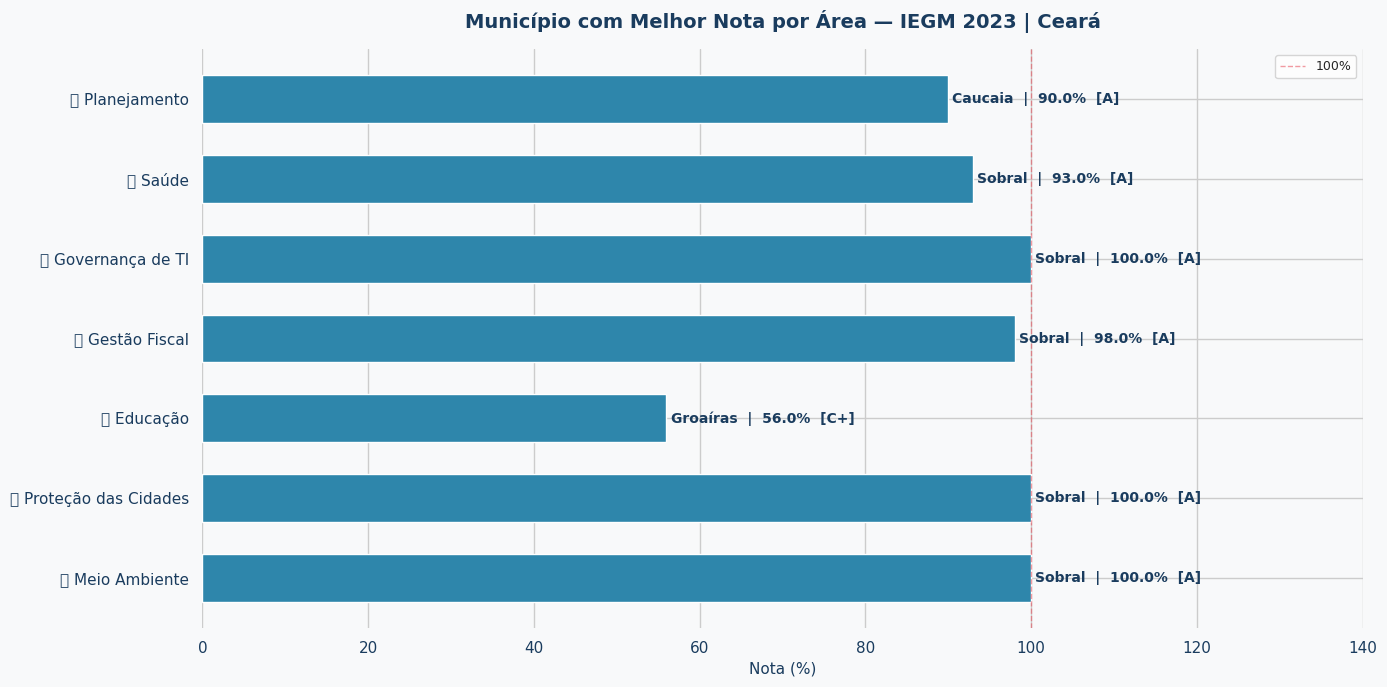

Gráfico salvo como 'melhores_por_area.png'


In [59]:
# =====================================================
# VISUALIZAÇÃO — MELHORES NOTAS POR ÁREA
# =====================================================

# PALETA DE CORES
CORES = {
    'fundo':      '#F8F9FA',
    'principal':  '#1A3C5E',
    'destaque':   '#2E86AB',
    'negativo':   '#E63946',
}

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(CORES['fundo'])
ax.set_facecolor(CORES['fundo'])

barras = ax.barh(
    df_melhores['Área'],
    df_melhores['Nota (%)'],
    color=CORES['destaque'],
    edgecolor='white',
    height=0.6
)

for bar, row in zip(barras, df_melhores.itertuples()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row.Município}  |  {row._3:.1f}%  [{row.Faixa}]",
        va='center', ha='left',
        fontsize=10, fontweight='bold', color=CORES['principal']
    )

ax.set_xlim(0, 140)
ax.set_xlabel('Nota (%)', fontsize=11, color=CORES['principal'])
ax.set_title('Município com Melhor Nota por Área — IEGM 2023 | Ceará',
             fontsize=14, fontweight='bold', pad=15, color=CORES['principal'])
ax.axvline(100, color=CORES['negativo'], linestyle='--', linewidth=1, alpha=0.5, label='100%')
ax.tick_params(colors=CORES['principal'])
ax.legend(fontsize=9)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('melhores_por_area.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'melhores_por_area.png'")

---

## Análise 2 — Respostas dos Municípios Destaque em Cada Área

Com os municípios identificados na análise anterior, o próximo passo é entender **por que eles se destacaram**.

Para isso, utilizamos a base `respostas_iegm_2023_TCECE_completo_nota.csv`, que contém todas as respostas enviadas por cada município ao questionário do IEGM, junto com a **nota atribuída a cada resposta**.

O cruzamento entre o município campeão de cada área e suas respostas nos permite responder:
- O que esse município declarou em cada questão?
- Quais respostas receberam pontuação e quais não receberam?

Para cada uma das sete áreas, será exibida uma tabela com:
- A **questão** avaliada
- A **resposta** enviada pelo município
- A **nota** recebida por aquela resposta

In [60]:
# =====================================================
# CONFIGURAÇÃO — ANÁLISE 2
# =====================================================

mapa_indicador = {
    'pct_iamb':    'i-Amb',
    'pct_icidade': 'i-Cidade',
    'pct_ieduc':   'i-Educ',
    'pct_ifiscal': 'i-Fiscal',
    'pct_igov_ti': 'i-Gov TI',
    'pct_isaude':  'i-Saude',
    'pct_iplan':   'i-Plan',
}

def get_respostas(coluna_pct):
    # Busca direto pelo índice do df_melhores
    idx = list(mapa_indicador.keys()).index(coluna_pct)
    row = df_melhores.iloc[idx]

    municipio = row['Município'].upper()
    indicador = mapa_indicador[coluna_pct]

    print(f"Buscando: municipio='{municipio}' | indicador='{indicador}'")

    df = df_respostas[
        (df_respostas['municipio'] == municipio) &
        (df_respostas['indicador'] == indicador)
    ][['chave_questao', 'questao', 'chave_resposta', 'resposta', 'nota']].copy()

    df.columns = ['Chave Questão', 'Questão', 'Chave Resposta', 'Resposta', 'Nota']
    return df.reset_index(drop=True), row

### Meio Ambiente (i-Amb):

In [61]:
df_amb, row = get_respostas('pct_iamb')
print(f"MEIO AMBIENTE — {row['Município']} | {row['Nota (%)']}% [{row['Faixa']}]")
display(df_amb)

Buscando: municipio='SOBRAL' | indicador='i-Amb'
MEIO AMBIENTE — Sobral | 100.0% [A]


,Chave Questão,Questão,Chave Resposta,Resposta,Nota
0,M05Q00900,A prefeitura possui alguma estrutura organizacional para tratar de assuntos ligados ao Meio Ambiente Municipal?,M05Q00900R00100,Sim,0.0
1,M05Q00910,A Prefeitura possui recursos humanos para operacionalização dos assuntos ligados ao Meio Ambiente?,M05Q00910R00100,Sim,5.0
2,M05Q00911R00100,Informe: Nº de efetivos:,,22,0.0
3,M05Q00911R00200,Informe: Nº de comissionados:,,41,0.0
4,M05Q00911R00300,Informe: Nº de terceirizados/contratados:,,117,0.0
...,...,...,...,...,...
105,M05Q04014R00200,Dados sobre drenagem e manejo de águas pluviais urbanas: Taxa de cobertura de vias públicas com redes ou canais pluviais subterrâneos:,,"13,4100",0.0
106,M05Q04014R00300,Dados sobre drenagem e manejo de águas pluviais urbanas: Parcela de domicílios em situação de risco de inundação:,,"1,5400",0.0
107,M05Q04100,Foi instituída taxa / tarifa de cobrança dos serviços de limpeza urbana e manejo de resíduos sólidos?,M05Q04100R00100,Sim,0.0
108,M05Q04200,O município utiliza balança para pesagem rotineira dos resíduos sólidos coletados?,M05Q04200R00100,Sim,5.0


### Proteção das Cidades (i-Cidade):

In [62]:
df_cidade, row = get_respostas('pct_icidade')
print(f"PROTEÇÃO DAS CIDADES — {row['Município']} | {row['Nota (%)']}% [{row['Faixa']}]")
display(df_cidade)

Buscando: municipio='SOBRAL' | indicador='i-Cidade'
PROTEÇÃO DAS CIDADES — Sobral | 100.0% [A]


,Chave Questão,Questão,Chave Resposta,Resposta,Nota
0,M06Q00100,"Foi criada a Coordenadoria Municipal de Proteção e Defesa Civil-COMPDEC ou órgão similar responsável pela execução, coordenação e mobilização de todas as ações de defesa civil no município?",M06Q00100R00100,Sim,50.0
1,M06Q00111R00100,Informe a página eletrônica (link na internet) do instrumento normativo que criou a Coordenadoria Municipal de Proteção e Defesa Civil-COMPDEC ou órgão similar:,,https://www.sobral.ce.gov.br/diario/public/files/diario/DOM1299_31-03-2022.pdf,0.0
2,M06Q00121,Assinale quais recursos a COMPDEC ou órgão similar possui:,"M06Q00121R00100, M06Q00121R00200, M06Q00121R00300, M06Q00121R00400, M06Q00121R00500, M06Q00121R00600","Estrutura Física, Outros, Recursos Humanos, Recursos Materiais, Recursos Orçamentários, Recursos Tecnológicos",50.0
3,M06Q00130,O Município possui Conselho Municipal de Proteção e Defesa Civil devidamente regulamentado?,M06Q00130R00100,Sim,10.0
4,M06Q00133R00100,Informe a página eletrônica (link na internet) do instrumento normativo do Conselho Municipal de Proteção e Defesa Civil:,,XYZ,0.0
5,M06Q00132,Quantas reuniões o Conselho realizou no ano de 2023?,M06Q00132R00100,8 ou mais reuniões,20.0
6,M06Q00800,"Sobre treinamento e capacitação sobre Proteção e Defesa Civil, a Prefeitura capacita seus agentes para ações municipais de Defesa Civil?",M06Q00800R00100,Sim,20.0
7,M06Q00820R00100,Qual a data da última capacitação dos agentes municipais para ações de Defesa Civil?,,29/09/2023,30.0
8,M06Q01900,"O Município realiza ações para estimular a participação de entidades privadas, associações de voluntários, clubes de serviços, organizações não governamentais e associações de classe e comunitárias?",M06Q01900R00100,Sim,10.0
9,M06Q01910,Assinale quais ações foram realizadas:,"M06Q01910R00100, M06Q01910R00200, M06Q01910R00300, M06Q01910R00400, M06Q01910R00500, M06Q01910R00600, M06Q01910R00700","Conferência, Congresso, Discussão na Câmara Municipal, Outros, Reunião, Treinamentos, Workshop / Palestra",0.0


### Educação (i-Educ):

In [63]:
df_educ, row = get_respostas('pct_ieduc')
print(f"EDUCAÇÃO — {row['Município']} | {row['Nota (%)']}% [{row['Faixa']}]")
display(df_educ)

Buscando: municipio='GROAÍRAS' | indicador='i-Educ'
EDUCAÇÃO — Groaíras | 56.0% [C+]


,Chave Questão,Questão,Chave Resposta,Resposta,Nota
0,M21Q06420R00200,Informe quantos estabelecimentos que oferecem Creche possuem Pátio Infantil (PI):,,1,0.666667
1,M01Q06431R00100,Informe quantos estabelecimentos que oferecem creche disponibilizam brinquedos/materiais pedagógicos:,,3,4.000000
2,M01Q06492R00100,Informe o número de crianças matriculadas na creche:,,299,0.000000
3,M01Q06495R00100,Informe a data de início de funcionamento para as creches:,,31/01/2022,0.000000
4,M01Q06480R00100,Informe a quantidade de estabelecimentos que oferecem Creche na rede municipal de ensino:,,3,0.000000
...,...,...,...,...,...
413,D01Q01011,Que tipo de apoio?,D01Q01011R00100,Deslocamento,0.000000
414,D01Q01012R00100,Anexar link que contém lista de frequência dos participantes nos cursos que abordam a temática educação ético- racial e indígena.,,https://groairas.ce.gov.br/site,0.000000
415,D01Q01100,Qual o maior desafio para a inserção dos conteúdos de história e cultura afro-brasileira e indígena nos currículos da rede escolar,D01Q01100R00500,Formação inicial docente deficiente para a educação das relações étnico-raciais.,0.000000
416,M01Q06300,"Gostaria de registrar suas impressões, comentários e sugestões a respeito do presente questionário?",M01Q06300R00100,Sim,0.000000


### Gestão Fiscal (i-Fiscal):

In [64]:
df_fiscal, row = get_respostas('pct_ifiscal')
print(f"GESTÃO FISCAL — {row['Município']} | {row['Nota (%)']}% [{row['Faixa']}]")
display(df_fiscal)

Buscando: municipio='SOBRAL' | indicador='i-Fiscal'
GESTÃO FISCAL — Sobral | 98.0% [A]


,Chave Questão,Questão,Chave Resposta,Resposta,Nota
0,M04Q00300,Há estrutura administrativa voltada para a administração tributária?,M04Q00300R00100,Sim,0.0
1,M04Q00330,A prefeitura dispõe de recursos humanos para a operacionalização das atividades relacionadas a administração tributária?,M04Q00330R00100,Sim,1.5
2,M04Q00331,Os fiscais tributários recebem treinamento específico para execução das atividades inerentes ao cargo?,M04Q00331R00100,Sim,10.0
3,M04Q00333,O Município possui Plano de Cargos e Salários específico para seus fiscais tributários?,M04Q00333R00200,Não,0.0
4,M04Q00340,Assinale os recursos disponibilizados para a operacionalização das atividades da administração tributária:,"M04Q00340R00200, M04Q00340R00300, M04Q00340R00400, M04Q00340R00500, M04Q00340R00600","Estrutura Física, Outros, Recursos Materiais, Recursos Orçamentários, Recursos Tecnológicos",7.5
...,...,...,...,...,...
167,F04Q04400,"No município, há contratação de empresas para prestação de serviços de assessoria jurídica e/ou assessoria tributária?",F04Q04400R00200,Não,0.0
168,F04Q04500,"No Município, há empresa contratada responsável pela cobrança judicial de tributos inscritos em Dívida Ativa?",F04Q04500R00200,Não,0.0
169,F04Q04600,"Existe implementada, no município, cobrança administrativa com busca ativa dos inadimplentes, definida como aquela em que ocorre, no mínimo, o envio de notificações aos devedores?",F04Q04600R00100,Sim,0.0
170,F04Q04700,"A Procuradoria municipal realiza controle das Certidões de Dívida Ativa, identificando se o crédito preenche todos os requisitos que lhe conferem certeza e liquidez?",F04Q04700R00100,Sim,0.0


### Governança de TI (i-Gov TI):

In [65]:
df_govti, row = get_respostas('pct_igov_ti')
print(f"GOVERNANÇA DE TI — {row['Município']} | {row['Nota (%)']}% [{row['Faixa']}]")
display(df_govti)

Buscando: municipio='SOBRAL' | indicador='i-Gov TI'
GOVERNANÇA DE TI — Sobral | 100.0% [A]


,Chave Questão,Questão,Chave Resposta,Resposta,Nota
0,M07Q03300,A Prefeitura possui uma área ou departamento de Tecnologia da Informação?,M07Q03300R00100,Sim,30.0
1,M07Q00300,O departamento de Tecnologia da Informação possui funcionários efetivos e/ou comissionados?,M07Q00300R00100,Sim,30.0
2,M07Q00310R00100,Informe a quantidade de funcionários efetivos:,,1,0.0
3,M07Q00310R00200,Informe a quantidade de funcionários comissionados,,1,0.0
4,M07Q00400,A prefeitura municipal definiu as atribuições do pessoal da área de Tecnologia da Informação?,M07Q00400R00100,Sim,30.0
5,M07Q00410R00100,"Informe o instrumento normativo, número e a data:",,https://www.sobral.ce.gov.br/diario/public/iom/IOM%2033_15-06-2000.pdf#page=15 https://www.sobral.ce.gov.br/diario/public/iom/IOM03.pdf#page=7 https://www.sobral.ce.gov.br/diario/public/iom/IOM02.pdf#page=16,0.0
6,M07Q00500,"A prefeitura disponibiliza, periodicamente, programas de capacitação e atualização para o pessoal da área de Tecnologia da Informação?",M07Q00500R00100,Sim,30.0
7,M07Q01000,"Sobre as compras públicas (licitações) que tenham como objeto equipamentos de TI, softwares ou serviços que envolvam a Tecnologia da Informação, há participação do pessoal de TI no processo de compra?",M07Q01000R00100,"Há participação do pessoal de TI no processo de compra (especificação técnica, comissão de julgamento, recebimento do objeto)",0.0
8,M07Q01010,Assinale as etapas que o pessoal de TI participa:,"M07Q01010R00100, M07Q01010R00200, M07Q01010R00300","Comissão de julgamento, Elaboração do edital / especificação técnica, Recebimento do objeto",40.0
9,M07Q03310,Informe os recursos disponibilizados para a operacionalização das atividades da Tecnologia da Informação:,"M07Q03310R00100, M07Q03310R00200, M07Q03310R00300, M07Q03310R00400, M07Q03310R00500","Estrutura Física, Outros, Recursos Materiais, Recursos Orçamentários, Recursos Tecnológicos",50.0


### Saúde (i-Saude):

In [66]:
df_saude, row = get_respostas('pct_isaude')
print(f"SAÚDE — {row['Município']} | {row['Nota (%)']}% [{row['Faixa']}]")
display(df_saude)

Buscando: municipio='SOBRAL' | indicador='i-Saude'
SAÚDE — Sobral | 93.0% [A]


,Chave Questão,Questão,Chave Resposta,Resposta,Nota
0,M02Q09400,As metas previstas para os indicadores do Plano Municipal de Saúde 2022-2025 foram atingidas?,M02Q09400R00100,"Sim, todas as metas foram atingidas",10.0
1,M02Q09900,O Conselho Municipal de Saúde participou da elaboração do Plano Municipal de Saúde 2022-2025?,M02Q09900R00100,"Sim, com propostas para construção das diretrizes e metas da saúde municipal",5.0
2,M02Q06100,Quando ocorreu a aprovação do Plano Municipal de Saúde 2022-2025 pelo Conselho Municipal da Saúde?,M02Q06100R00100,Até prazo de envio à Câmara Municipal do projeto de lei sobre PPA 2022-2025,10.0
3, ,Informe sobre a situação de aprovação do Programação Anual de Saúde de 2023 pelo Conselho Municipal de Saúde?, ,Aprovado,0.0
4,M02Q06210,As ações previstas na Programação Anual de Saúde de 2023 foram executadas?,M02Q06210R00100,"Sim, todas as ações foram executadas",4.0
...,...,...,...,...,...
249,M02Q10700R00600,Informe: Total de diabéticos - 3º Quadrimestre de 2023:,,10824,0.0
250,M02Q06000R00100,Aplicação do mínimo constitucional em saúde: Despesa aplicada em Saúde com recursos próprios:,,"103408345,8200",0.0
251,M02Q06000R00200,Aplicação do mínimo constitucional em saúde: Receita de Impostos (Saúde):,,"103408345,8200",0.0
252,TCMGO00100,"Qual foi o valor gasto com saúde no exercício de 2023, decorrente de decisões judiciais?",,"456699,9300",0.0


### Planejamento (i-Plan):

In [68]:
df_plan, row = get_respostas('pct_iplan')
print(f"PLANEJAMENTO — {row['Município']} | {row['Nota (%)']}% [{row['Faixa']}]")
display(df_plan)

Buscando: municipio='CAUCAIA' | indicador='i-Plan'
PLANEJAMENTO — Caucaia | 90.0% [A]


,Chave Questão,Questão,Chave Resposta,Resposta,Nota
0,M03Q08000,"O planejamento da prefeitura, para o ano de 2022 foi estruturado através de programas, indicadores, metas e ações",M03Q08000R00100,Sim,0.0
1,M03Q08100R00100,Quantidade de Programas:,,24,500.0
2,CODPROG,Código do Programa,,101,0.0
3,DESPROG,Descrição do Programa,,GEST?O DA ARTE E DA CULTURA,0.0
4,VLRESTI,Valor Estimado do Indicador,,"12,0000",0.0
...,...,...,...,...,...
473,M03Q08200R00100,Informe o valor total da dotação inicial autorizada pela Lei Orçamentária Anual (LOA) para o ano de 2023,,"1548044000,0000",0.0
474,M03Q08200R00200,Informe o valor total da dotação atualizada em 31/12/2023,,"1548044000,0000",0.0
475,M03Q08400,Pontualidade na Entrega dos Documentos relativos às Peças de Planejamento,M03Q08400R00100,Planejamento entregue no prazo,150.0
476,M03Q08500,O município aderiu ao Programa Nacional de Prevenção à Corrupção (PNPC) por meio do questionário de integridade no sistema e-Prevenção?,M03Q08500R00100,Sim,0.0


### Exportar todas as respostas em CSV

In [69]:
dfs_areas = {
    'iamb':    get_respostas('pct_iamb'),
    'icidade': get_respostas('pct_icidade'),
    'ieduc':   get_respostas('pct_ieduc'),
    'ifiscal': get_respostas('pct_ifiscal'),
    'igov_ti': get_respostas('pct_igov_ti'),
    'isaude':  get_respostas('pct_isaude'),
    'iplan':   get_respostas('pct_iplan'),
}

for area, (df, row) in dfs_areas.items():
    nome_arquivo = f"respostas_{area}_{row['Município'].upper()}.csv"
    df.to_csv(nome_arquivo, index=False, sep=';', encoding='utf-8-sig')
    print(f"✅ {nome_arquivo}")

Buscando: municipio='SOBRAL' | indicador='i-Amb'
Buscando: municipio='SOBRAL' | indicador='i-Cidade'
Buscando: municipio='GROAÍRAS' | indicador='i-Educ'
Buscando: municipio='SOBRAL' | indicador='i-Fiscal'
Buscando: municipio='SOBRAL' | indicador='i-Gov TI'
Buscando: municipio='SOBRAL' | indicador='i-Saude'
Buscando: municipio='CAUCAIA' | indicador='i-Plan'
✅ respostas_iamb_SOBRAL.csv
✅ respostas_icidade_SOBRAL.csv
✅ respostas_ieduc_GROAÍRAS.csv
✅ respostas_ifiscal_SOBRAL.csv
✅ respostas_igov_ti_SOBRAL.csv
✅ respostas_isaude_SOBRAL.csv
✅ respostas_iplan_CAUCAIA.csv


---

## Curiosidade: Comparação de Respostas: Sobral vs. Município Destaque

Ao longo da análise, ficou evidente que **Sobral** foi o município com melhor desempenho na maioria das áreas do IEGM 2023, ficando em primeiro lugar em **cinco das sete áreas** avaliadas.

No entanto, em duas áreas específicas — **Educação** e **Planejamento** — Sobral não ocupou a primeira posição. Para entender o que fez a diferença, vamos comparar as respostas enviadas pelo município campeão de cada uma dessas áreas com as respostas de Sobral.

O objetivo é identificar **quais questões foram respondidas de forma diferente** e como isso impactou a nota final.

### COMPARAÇÃO I-EDUC — Groaíras vs Sobral

In [93]:
# Indicador analisado
indicador = 'i-Educ'

row_educ = df_melhores.iloc[list(mapa_indicador.keys()).index('pct_ieduc')]
municipio_camp = row_educ['Município'].upper()

cols = ['indice_questao', 'chave_questao', 'questao', 'chave_resposta', 'resposta', 'nota']

df_camp = df_respostas[
    (df_respostas['municipio'] == municipio_camp) &
    (df_respostas['indicador'] == indicador)
][cols].reset_index(drop=True)

df_sobral = df_respostas[
    (df_respostas['municipio'] == 'SOBRAL') &
    (df_respostas['indicador'] == indicador)
][cols].reset_index(drop=True)

# Monta lado a lado por posição — sem merge
df_comp_educ = pd.DataFrame({
    'Índice Questão':                    df_camp['indice_questao'],
    'Chave Questão':                     df_camp['chave_questao'],
    'Questão':                           df_camp['questao'],
    f'Chave Resposta {municipio_camp}':  df_camp['chave_resposta'],
    f'Resposta {municipio_camp}':        df_camp['resposta'],
    f'Nota {municipio_camp}':            df_camp['nota'],
    f'Chave Resposta SOBRAL':            df_sobral['chave_resposta'],
    f'Resposta SOBRAL':                  df_sobral['resposta'],
    f'Nota SOBRAL':                      df_sobral['nota'],
})

print(f"EDUCAÇÃO — {municipio_camp} ({row_educ['Nota (%)']}% [{row_educ['Faixa']}]) vs SOBRAL")
print(f"Linhas {municipio_camp}: {len(df_camp)} | Linhas SOBRAL: {len(df_sobral)}")
display(df_comp_educ)

df_comp_educ.to_csv(f'comparacao_ieduc_{municipio_camp}_vs_SOBRAL.csv', index=False, sep=';', encoding='utf-8-sig')
print(f"CSV salvo: comparacao_ieduc_{municipio_camp}_vs_SOBRAL.csv")

EDUCAÇÃO — GROAÍRAS (56.0% [C+]) vs SOBRAL
Linhas GROAÍRAS: 418 | Linhas SOBRAL: 450


,Índice Questão,Chave Questão,Questão,Chave Resposta GROAÍRAS,Resposta GROAÍRAS,Nota GROAÍRAS,Chave Resposta SOBRAL,Resposta SOBRAL,Nota SOBRAL
0,001.,M21Q06420R00200,Informe quantos estabelecimentos que oferecem Creche possuem Pátio Infantil (PI):,,1,0.666667,,29,1.348837
1,002.,M01Q06431R00100,Informe quantos estabelecimentos que oferecem creche disponibilizam brinquedos/materiais pedagógicos:,,3,4.000000,,37,3.441860
2,003.,M01Q06492R00100,Informe o número de crianças matriculadas na creche:,,299,0.000000,,4943,0.000000
3,004.,M01Q06495R00100,Informe a data de início de funcionamento para as creches:,,31/01/2022,0.000000,,01/02/2022,0.000000
4,005.,M01Q06480R00100,Informe a quantidade de estabelecimentos que oferecem Creche na rede municipal de ensino:,,3,0.000000,,43,0.000000
...,...,...,...,...,...,...,...,...,...
445,NaN,NaN,NaN,NaN,NaN,NaN,,"Aos Professores de distritos são ofertados serviços de transporte para deslocamento até o local da formação e retorno à sua localidade. Formação realizada dentro do turno de trabalho, contemplando o tempo destinado para planejamento, contemplado pelo ? de carga horária destinada para estudos.",0.000000
446,NaN,NaN,NaN,NaN,NaN,NaN,,https://drive.google.com/drive/folders/1DElTc21md1ngUTU_8a7vua4TrGoDd_Pz,0.000000
447,NaN,NaN,NaN,NaN,NaN,NaN,D01Q01100R00500,Formação inicial docente deficiente para a educação das relações étnico-raciais.,0.000000
448,NaN,NaN,NaN,NaN,NaN,NaN,M01Q06300R00100,Sim,0.000000


CSV salvo: comparacao_ieduc_GROAÍRAS_vs_SOBRAL.csv


### COMPARAÇÃO I-PLAN — Caucaia vs Sobral

In [94]:
# Indicador analisado
indicador = 'i-Plan'

row_plan = df_melhores.iloc[list(mapa_indicador.keys()).index('pct_iplan')]
municipio_camp = row_plan['Município'].upper()

cols = ['indice_questao', 'chave_questao', 'questao', 'chave_resposta', 'resposta', 'nota']

df_camp = df_respostas[
    (df_respostas['municipio'] == municipio_camp) &
    (df_respostas['indicador'] == indicador)
][cols].reset_index(drop=True)

df_sobral = df_respostas[
    (df_respostas['municipio'] == 'SOBRAL') &
    (df_respostas['indicador'] == indicador)
][cols].reset_index(drop=True)

# Monta lado a lado por posição — sem merge
df_comp_plan = pd.DataFrame({
    'Índice Questão':                  df_camp['indice_questao'],
    'Chave Questão':                   df_camp['chave_questao'],
    'Questão':                         df_camp['questao'],
    f'Chave Resposta {municipio_camp}': df_camp['chave_resposta'],
    f'Resposta {municipio_camp}':       df_camp['resposta'],
    f'Nota {municipio_camp}':           df_camp['nota'],
    f'Chave Resposta SOBRAL':           df_sobral['chave_resposta'],
    f'Resposta SOBRAL':                 df_sobral['resposta'],
    f'Nota SOBRAL':                     df_sobral['nota'],
})

print(f"PLANEJAMENTO — {municipio_camp} ({row_plan['Nota (%)']}% [{row_plan['Faixa']}]) vs SOBRAL")
print(f"Linhas {municipio_camp}: {len(df_camp)} | Linhas SOBRAL: {len(df_sobral)}")
display(df_comp_plan)

df_comp_plan.to_csv(f'comparacao_iplan_{municipio_camp}_vs_SOBRAL.csv', index=False, sep=';', encoding='utf-8-sig')
print(f"CSV salvo: comparacao_iplan_{municipio_camp}_vs_SOBRAL.csv")

PLANEJAMENTO — CAUCAIA (90.0% [A]) vs SOBRAL
Linhas CAUCAIA: 478 | Linhas SOBRAL: 357


,Índice Questão,Chave Questão,Questão,Chave Resposta CAUCAIA,Resposta CAUCAIA,Nota CAUCAIA,Chave Resposta SOBRAL,Resposta SOBRAL,Nota SOBRAL
0,001.,M03Q08000,"O planejamento da prefeitura, para o ano de 2022 foi estruturado através de programas, indicadores, metas e ações",M03Q08000R00100,Sim,0.0,M03Q08000R00100,Sim,0.0
1,001.001.,M03Q08100R00100,Quantidade de Programas:,,24,500.0,,53,0.0
2,001.001.001.,CODPROG,Código do Programa,,101,0.0,,101,0.0
3,001.001.002.,DESPROG,Descrição do Programa,,GEST?O DA ARTE E DA CULTURA,0.0,,MODERNIZAÇÃO DA GESTÃO PÚBLICA E RECURSOS LOGÍSTICOS,0.0
4,001.001.005.,VLRESTI,Valor Estimado do Indicador,,"12,0000",0.0,,"100,0000",0.0
...,...,...,...,...,...,...,...,...,...
473,021.,M03Q08200R00100,Informe o valor total da dotação inicial autorizada pela Lei Orçamentária Anual (LOA) para o ano de 2023,,"1548044000,0000",0.0,NaN,NaN,NaN
474,022.,M03Q08200R00200,Informe o valor total da dotação atualizada em 31/12/2023,,"1548044000,0000",0.0,NaN,NaN,NaN
475,023.,M03Q08400,Pontualidade na Entrega dos Documentos relativos às Peças de Planejamento,M03Q08400R00100,Planejamento entregue no prazo,150.0,NaN,NaN,NaN
476,024.,M03Q08500,O município aderiu ao Programa Nacional de Prevenção à Corrupção (PNPC) por meio do questionário de integridade no sistema e-Prevenção?,M03Q08500R00100,Sim,0.0,NaN,NaN,NaN


CSV salvo: comparacao_iplan_CAUCAIA_vs_SOBRAL.csv
